<a href="https://colab.research.google.com/github/vishaleswari1813-cpu/CSA0710-CN/blob/main/Title2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()
print("Uploaded files:", list(uploaded.keys()))

Saving archive (3).zip to archive (3).zip
Saving archive (2).zip to archive (2).zip
Saving archive (1).zip to archive (1).zip
Saving archive (6).zip to archive (6).zip
Uploaded files: ['archive (3).zip', 'archive (2).zip', 'archive (1).zip', 'archive (6).zip']


In [2]:
import os
import zipfile

base_path = "/content/datasets"
os.makedirs(base_path, exist_ok=True)

zip_files = [f for f in uploaded.keys() if f.endswith(".zip")]

dataset_dirs = []

for zip_file in zip_files:
    dataset_name = os.path.splitext(zip_file)[0]   # removes .zip
    extract_path = os.path.join(base_path, dataset_name)
    os.makedirs(extract_path, exist_ok=True)

    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    dataset_dirs.append(extract_path)
    print(f"Extracted {zip_file} -> {extract_path}")

print("\nAll dataset folders:")
for d in dataset_dirs:
    print(d)

Extracted archive (3).zip -> /content/datasets/archive (3)
Extracted archive (2).zip -> /content/datasets/archive (2)
Extracted archive (1).zip -> /content/datasets/archive (1)
Extracted archive (6).zip -> /content/datasets/archive (6)

All dataset folders:
/content/datasets/archive (3)
/content/datasets/archive (2)
/content/datasets/archive (1)
/content/datasets/archive (6)


In [3]:
import glob
import pandas as pd

summary = []

for folder in dataset_dirs:
    dataset_name = os.path.basename(folder)

    csv_files = glob.glob(folder + "/**/*.csv", recursive=True)
    jpg_files = glob.glob(folder + "/**/*.jpg", recursive=True)
    png_files = glob.glob(folder + "/**/*.png", recursive=True)
    jpeg_files = glob.glob(folder + "/**/*.jpeg", recursive=True)
    image_files = jpg_files + png_files + jpeg_files

    total_files = glob.glob(folder + "/**/*", recursive=True)
    total_files = [f for f in total_files if os.path.isfile(f)]

    summary.append({
        "Dataset": dataset_name,
        "Total Files": len(total_files),
        "CSV Files": len(csv_files),
        "Image Files": len(image_files),
        "Folder Path": folder
    })

summary_df = pd.DataFrame(summary)
summary_df

,Dataset,Total Files,CSV Files,Image Files,Folder Path
0,archive (3),1,1,0,/content/datasets/archive (3)
1,archive (2),1,1,0,/content/datasets/archive (2)
2,archive (1),1,1,0,/content/datasets/archive (1)
3,archive (6),1,1,0,/content/datasets/archive (6)


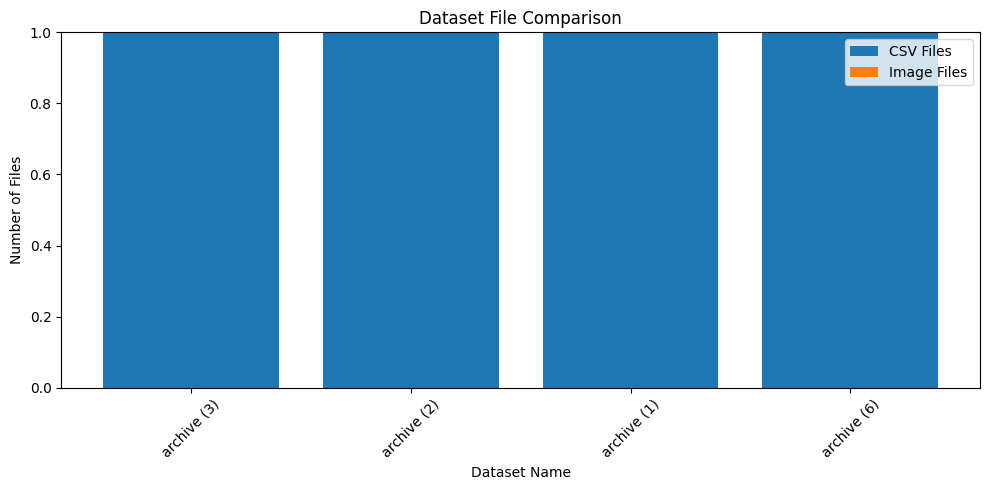

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
x = summary_df["Dataset"]

plt.bar(x, summary_df["CSV Files"], label="CSV Files")
plt.bar(x, summary_df["Image Files"], bottom=summary_df["CSV Files"], label="Image Files")

plt.title("Dataset File Comparison")
plt.xlabel("Dataset Name")
plt.ylabel("Number of Files")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
all_csv_data = {}

for folder in dataset_dirs:
    dataset_name = os.path.basename(folder)
    csv_files = glob.glob(folder + "/**/*.csv", recursive=True)

    if len(csv_files) == 0:
        print(f"\nNo CSV files found in {dataset_name}")
        continue

    print(f"\n===== {dataset_name} =====")

    dataset_frames = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)
            dataset_frames.append(df)

            print(f"\nFile: {file}")
            print("Shape:", df.shape)
            display(df.head())
        except Exception as e:
            print(f"Could not read {file}: {e}")

    if dataset_frames:
        all_csv_data[dataset_name] = pd.concat(dataset_frames, ignore_index=True, sort=False)


===== archive (3) =====

File: /content/datasets/archive (3)/capstone_smartgrid_20000.csv
Shape: (20000, 31)


,meter_id,timestamp,region,building_type,floor_area_m2,insulation_rating,hvac_age_years,solar_kw_installed,ev_charger,hour,...,consumption_kwh,next_hour_consumption_kwh,lag1_kwh,lag24_kwh,roll24_mean_kwh,roll24_std_kwh,high_usage_flag,anomaly_flag,sensor_health,outage_risk_score
0,M001,2025-01-01 00:00:00,W,commercial,113,0.709966,16.486924,2.762723,1,0,...,2.7074,2.5389,NaN,NaN,2.7074,NaN,0,0,0.973,0.1012
1,M001,2025-01-01 01:00:00,W,commercial,113,0.709966,16.486924,2.762723,1,1,...,2.5389,2.6194,2.7074,NaN,2.6232,0.1191,0,0,0.979,0.1195
2,M001,2025-01-01 02:00:00,W,commercial,113,0.709966,16.486924,2.762723,1,2,...,2.6194,2.3420,2.5389,NaN,2.6219,0.0843,0,0,0.940,0.1562
3,M001,2025-01-01 03:00:00,W,commercial,113,0.709966,16.486924,2.762723,1,3,...,2.3420,2.6295,2.6194,NaN,2.5519,0.1560,0,0,0.943,0.1309
4,M001,2025-01-01 04:00:00,W,commercial,113,0.709966,16.486924,2.762723,1,4,...,2.6295,2.2090,2.3420,NaN,2.5674,0.1394,0,0,0.995,0.1704



===== archive (2) =====

File: /content/datasets/archive (2)/smartgrid_5yr_hourly_natural.csv
Shape: (43848, 14)


,timestamp,hour,weekday,is_weekend,month,season_dry,season_rainy,season_harmattan,temperature,is_rain_day,holiday_type_national,holiday_type_religious,is_lockdown,load_kw
0,2020-01-01 00:00:00,0,2,0,1,False,False,True,25.2,0,1,0,0,36521.785383
1,2020-01-01 01:00:00,1,2,0,1,False,False,True,25.2,0,1,0,0,34934.339247
2,2020-01-01 02:00:00,2,2,0,1,False,False,True,25.2,0,1,0,0,36899.221345
3,2020-01-01 03:00:00,3,2,0,1,False,False,True,25.2,0,1,0,0,39087.574641
4,2020-01-01 04:00:00,4,2,0,1,False,False,True,25.2,0,1,0,0,34694.616563



===== archive (1) =====

File: /content/datasets/archive (1)/household_energy_consumption.csv
Shape: (90000, 7)


,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
0,H00001,2025-04-01,8.4,4,17.8,No,3.2
1,H00001,2025-04-02,7.9,4,17.3,No,2.8
2,H00001,2025-04-03,9.2,4,18.6,No,3.0
3,H00001,2025-04-04,7.9,4,18.2,No,2.7
4,H00001,2025-04-05,9.6,4,11.9,No,3.2



===== archive (6) =====

File: /content/datasets/archive (6)/charging_ev_and_grid_optimization_dataset.csv
Shape: (8354, 27)


,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,...,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
0,1/1/2025 0:00,ST004,Urban,EV10000,Two-Wheeler,1/1/2025 0:00,1/1/2025 0:12,1/1/2025 4:33,12,60,...,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,CH4,Low,-8.622299
1,1/1/2025 0:15,ST005,Urban,EV10001,Two-Wheeler,1/1/2025 0:15,1/1/2025 0:23,1/1/2025 1:12,8,100,...,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,CH9,Low,-1.935644
2,1/1/2025 0:30,ST019,Highway,EV10002,Car,1/1/2025 0:30,1/1/2025 0:41,1/1/2025 1:35,11,75,...,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,CH2,Low,-18.201846
3,1/1/2025 0:45,ST008,Urban,EV10003,Two-Wheeler,1/1/2025 0:45,1/1/2025 0:54,1/1/2025 3:29,9,40,...,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,CH9,Medium,-7.404018
4,1/1/2025 1:00,ST008,Highway,EV10004,Two-Wheeler,1/1/2025 1:00,1/1/2025 1:08,1/1/2025 6:14,8,75,...,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,CH1,Low,-6.577466


In [6]:
for dataset_name, df in all_csv_data.items():
    print(f"\n========== Statistical Summary: {dataset_name} ==========")
    display(df.describe(include='all'))


========== Statistical Summary: archive (3) ==========


,meter_id,timestamp,region,building_type,floor_area_m2,insulation_rating,hvac_age_years,solar_kw_installed,ev_charger,hour,...,consumption_kwh,next_hour_consumption_kwh,lag1_kwh,lag24_kwh,roll24_mean_kwh,roll24_std_kwh,high_usage_flag,anomaly_flag,sensor_health,outage_risk_score
count,20000,20000,20000,20000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,19960.000000,19960.000000,19040.000000,20000.000000,19960.000000,20000.000000,20000.000000,20000.000000,20000.000000
unique,40,500,5,3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,M001,2025-01-21 19:00:00,SW,residential,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,500,40,5500,11500,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,175.10000,0.632075,8.392352,3.181894,0.525000,11.420000,...,1.556633,1.555151,1.555237,1.554614,1.572026,0.909037,0.100000,0.004400,0.971101,0.114137
std,NaN,NaN,NaN,NaN,66.89816,0.128387,4.299919,1.826699,0.499387,6.891007,...,1.795416,1.794545,1.795573,1.796102,1.463914,0.592078,0.300008,0.066188,0.015973,0.043991
min,NaN,NaN,NaN,NaN,72.00000,0.390902,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.237700,0.006200,0.000000,0.000000,0.850000,0.000000
25%,NaN,NaN,NaN,NaN,122.75000,0.513387,5.239790,2.141524,0.000000,5.000000,...,0.182725,0.178125,0.178125,0.178125,0.760300,0.566300,0.000000,0.000000,0.961000,0.084100
50%,NaN,NaN,NaN,NaN,158.00000,0.617925,7.905142,3.025510,1.000000,11.000000,...,1.236600,1.236050,1.235250,1.238400,1.140600,0.745900,0.000000,0.000000,0.972000,0.111000
75%,NaN,NaN,NaN,NaN,236.25000,0.711265,10.189301,4.423859,1.000000,17.000000,...,2.121375,2.119100,2.119700,2.114350,1.608525,1.073400,0.000000,0.000000,0.982000,0.140300



========== Statistical Summary: archive (2) ==========


,timestamp,hour,weekday,is_weekend,month,season_dry,season_rainy,season_harmattan,temperature,is_rain_day,holiday_type_national,holiday_type_religious,is_lockdown,load_kw
count,43848,43848.000000,43848.000000,43848.000000,43848.000000,43848,43848,43848,43848.000000,43848.000000,43848.000000,43848.000000,43848.0,43848.000000
unique,43848,NaN,NaN,NaN,NaN,2,2,2,NaN,NaN,NaN,NaN,NaN,NaN
top,2024-12-31 23:00:00,NaN,NaN,NaN,NaN,False,True,False,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,36720,25680,32808,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,11.500000,3.000000,0.285714,6.521073,NaN,NaN,NaN,30.838515,0.251779,0.008210,0.013684,0.0,82539.455411
std,NaN,6.922265,2.000023,0.451759,3.449252,NaN,NaN,NaN,4.858355,0.434040,0.090238,0.116175,0.0,27243.529138
min,NaN,0.000000,0.000000,0.000000,1.000000,NaN,NaN,NaN,25.200000,0.000000,0.000000,0.000000,0.0,16871.445925
25%,NaN,5.750000,1.000000,0.000000,4.000000,NaN,NaN,NaN,27.000000,0.000000,0.000000,0.000000,0.0,59879.966747
50%,NaN,11.500000,3.000000,0.000000,7.000000,NaN,NaN,NaN,30.000000,0.000000,0.000000,0.000000,0.0,79160.447493
75%,NaN,17.250000,5.000000,1.000000,10.000000,NaN,NaN,NaN,33.600000,1.000000,0.000000,0.000000,0.0,106441.937693



========== Statistical Summary: archive (1) ==========


,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
count,90000,90000,90000.000000,90000.000000,90000.000000,90000,90000.000000
unique,12857,8,NaN,NaN,NaN,2,NaN
top,H12857,2025-04-01,NaN,NaN,NaN,No,NaN
freq,8,12857,NaN,NaN,NaN,45508,NaN
mean,NaN,NaN,10.571988,3.487811,17.505802,NaN,4.319557
std,NaN,NaN,5.519494,1.709761,2.491621,NaN,2.531432
min,NaN,NaN,0.500000,1.000000,10.000000,NaN,0.200000
25%,NaN,NaN,6.000000,2.000000,15.800000,NaN,2.300000
50%,NaN,NaN,10.400000,3.000000,17.500000,NaN,4.000000
75%,NaN,NaN,14.800000,5.000000,19.200000,NaN,6.000000



========== Statistical Summary: archive (6) ==========


,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,...,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
count,8354,8354,8354,8354,8354,8354,8354,8354,8354.000000,8354.000000,...,8354.000000,8354.000000,8354,8354,8354,8354,8354.000000,8354,8354,8354.000000
unique,8354,20,2,8354,3,8354,8304,8109,NaN,NaN,...,NaN,NaN,3,3,7,2,NaN,10,3,NaN
top,3/29/2025 0:15,ST013,Urban,EV18353,Car,3/29/2025 0:15,1/26/2025 22:02,1/2/2025 1:03,NaN,NaN,...,NaN,NaN,Low,Rainy,Wednesday,Off-Peak,NaN,CH7,Medium,NaN
freq,1,459,4188,1,2833,1,2,3,NaN,NaN,...,NaN,NaN,3134,2854,1248,5222,NaN,904,2913,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.526335,61.079722,...,9.959945,0.354101,NaN,NaN,NaN,NaN,53.156126,NaN,NaN,-11.834559
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.894049,25.001163,...,2.878798,0.186150,NaN,NaN,NaN,NaN,27.563387,NaN,NaN,9.271940
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,30.000000,...,5.000000,0.100157,NaN,NaN,NaN,NaN,5.505723,NaN,NaN,-43.285910
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,40.000000,...,7.510000,0.207315,NaN,NaN,NaN,NaN,27.911603,NaN,NaN,-18.354606
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,60.000000,...,9.955000,0.313459,NaN,NaN,NaN,NaN,49.513337,NaN,NaN,-11.268337
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.000000,75.000000,...,12.397500,0.462315,NaN,NaN,NaN,NaN,77.845036,NaN,NaN,-5.106912


In [7]:
missing_summary = []

for dataset_name, df in all_csv_data.items():
    total_missing = df.isnull().sum().sum()
    missing_summary.append({
        "Dataset": dataset_name,
        "Missing Values": total_missing,
        "Rows": df.shape[0],
        "Columns": df.shape[1]
    })

missing_df = pd.DataFrame(missing_summary)
display(missing_df)

,Dataset,Missing Values,Rows,Columns
0,archive (3),1080,20000,31
1,archive (2),0,43848,14
2,archive (1),0,90000,7
3,archive (6),0,8354,27


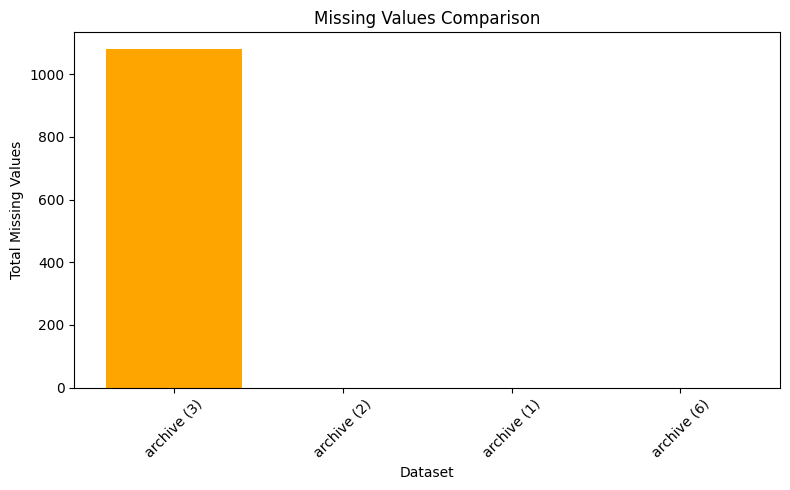

In [8]:
plt.figure(figsize=(8,5))
plt.bar(missing_df["Dataset"], missing_df["Missing Values"], color="orange")
plt.title("Missing Values Comparison")
plt.xlabel("Dataset")
plt.ylabel("Total Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
size_summary = []

for dataset_name, df in all_csv_data.items():
    size_summary.append({
        "Dataset": dataset_name,
        "Rows": df.shape[0],
        "Columns": df.shape[1]
    })

size_df = pd.DataFrame(size_summary)
display(size_df)

,Dataset,Rows,Columns
0,archive (3),20000,31
1,archive (2),43848,14
2,archive (1),90000,7
3,archive (6),8354,27


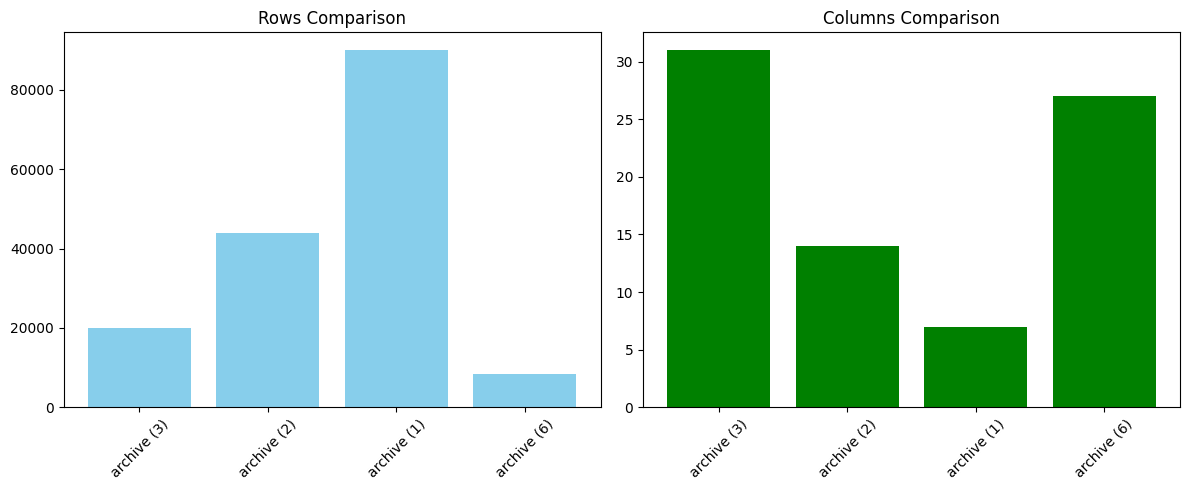

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].bar(size_df["Dataset"], size_df["Rows"], color="skyblue")
ax[0].set_title("Rows Comparison")
ax[0].tick_params(axis='x', rotation=45)

ax[1].bar(size_df["Dataset"], size_df["Columns"], color="green")
ax[1].set_title("Columns Comparison")
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [11]:
import cv2

for folder in dataset_dirs:
    dataset_name = os.path.basename(folder)
    image_files = glob.glob(folder + "/**/*.jpg", recursive=True)
    image_files += glob.glob(folder + "/**/*.png", recursive=True)
    image_files += glob.glob(folder + "/**/*.jpeg", recursive=True)

    if len(image_files) == 0:
        print(f"\nNo images found in {dataset_name}")
        continue

    print(f"\nSample images from {dataset_name}")

    for img_path in image_files[:3]:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(4,4))
        plt.imshow(img)
        plt.title(os.path.basename(img_path))
        plt.axis("off")
        plt.show()


No images found in archive (3)

No images found in archive (2)

No images found in archive (1)

No images found in archive (6)


In [12]:
print("========== FINAL DATASET COMPARISON ==========")
display(summary_df)

if len(all_csv_data) > 0:
    display(size_df)
    display(missing_df)
else:
    print("No CSV datasets available for statistical comparison.")

========== FINAL DATASET COMPARISON ==========


,Dataset,Total Files,CSV Files,Image Files,Folder Path
0,archive (3),1,1,0,/content/datasets/archive (3)
1,archive (2),1,1,0,/content/datasets/archive (2)
2,archive (1),1,1,0,/content/datasets/archive (1)
3,archive (6),1,1,0,/content/datasets/archive (6)


,Dataset,Rows,Columns
0,archive (3),20000,31
1,archive (2),43848,14
2,archive (1),90000,7
3,archive (6),8354,27


,Dataset,Missing Values,Rows,Columns
0,archive (3),1080,20000,31
1,archive (2),0,43848,14
2,archive (1),0,90000,7
3,archive (6),0,8354,27
